# Moving Average Strategies

Each section is self-contained: it sets its own parameters and redefines its helper functions, so run the notebook top to bottom (or start any section after running the imports).

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

## Simple moving average

50-period SMA over SMT.L closes.

In [ ]:
df = yf.Ticker("SMT.L").history(period="max")

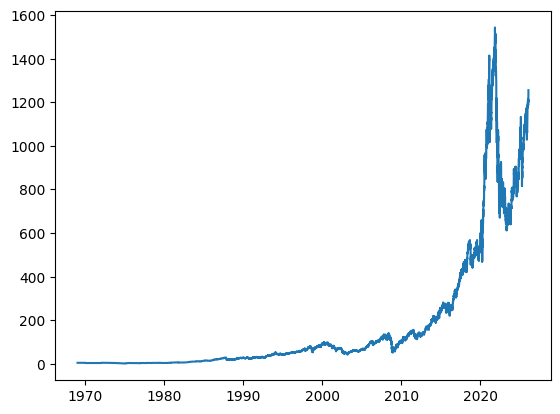

In [ ]:
plt.plot(df['Close'])

In [ ]:
df['MA'] = df['Close'].rolling(50).mean()
df

,Open,High,Low,Close,Volume,Dividends,Stock Splits,MA
Date,,,,,,,,
1968-12-31 00:00:00+01:00,4.802247,4.802247,4.802247,4.802247,0,0.0,0.0,NaN
1969-01-01 00:00:00+01:00,4.802247,4.802247,4.802247,4.802247,0,0.0,0.0,NaN
1969-01-02 00:00:00+01:00,4.802247,4.802247,4.802247,4.802247,0,0.0,0.0,NaN
1969-01-03 00:00:00+01:00,4.802247,4.802247,4.802247,4.802247,0,0.0,0.0,NaN
1969-01-06 00:00:00+01:00,4.802247,4.802247,4.802247,4.802247,0,0.0,0.0,NaN
...,...,...,...,...,...,...,...,...
2026-01-26 00:00:00+00:00,1207.500000,1210.000000,1196.000000,1202.000000,1558929,0.0,0.0,1141.038372
2026-01-27 00:00:00+00:00,1204.500000,1211.500000,1201.500000,1210.000000,1395721,0.0,0.0,1143.278704
2026-01-28 00:00:00+00:00,1218.000000,1239.000000,1211.000000,1235.500000,2159765,0.0,0.0,1146.199033


Text(0.5, 1.0, 'SMT.L Close vs. Moving Average')

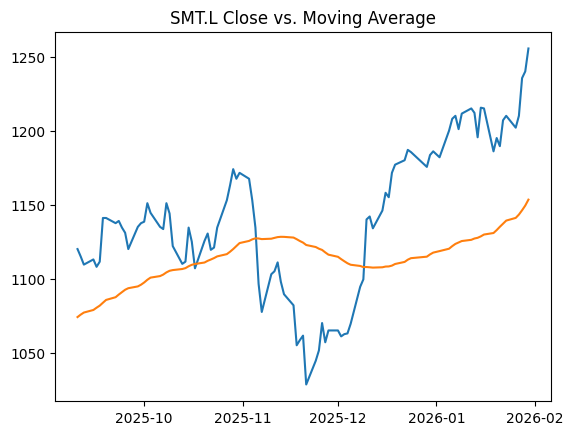

In [ ]:
TICKER = 'SMT.L'

df = yf.Ticker(TICKER).history(period="max")
df['MA'] = df['Close'].rolling(50).mean()

df = df.iloc[-100:, :] #last 100 row, all columns

plt.plot(df['Close']) 
plt.plot(df['MA'])
plt.title(f'{TICKER} Close vs. Moving Average')

## Price vs. moving average strategy

Long when SPY closes above its moving average, short when below.

In [ ]:
df = yf.Ticker("SPY").history(period="max")

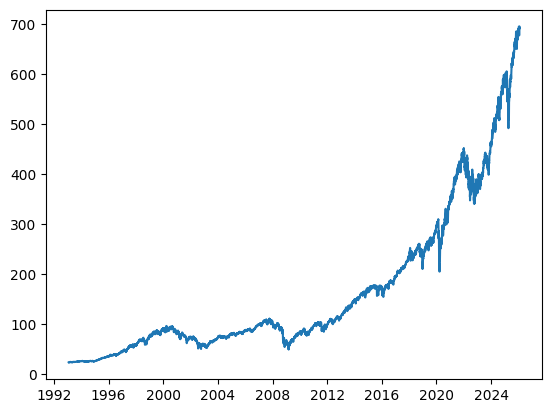

In [ ]:
plt.plot(df['Close'])

In [ ]:
df['MA'] = df['Close'].rolling(50).mean()
df

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains,MA
Date,,,,,,,,,
1993-01-29 00:00:00-05:00,24.258643,24.258643,24.137953,24.241402,1003200,0.0,0.0,0.0,NaN
1993-02-01 00:00:00-05:00,24.258640,24.413813,24.258640,24.413813,480500,0.0,0.0,0.0,NaN
1993-02-02 00:00:00-05:00,24.396576,24.482783,24.344852,24.465542,201300,0.0,0.0,0.0,NaN
1993-02-03 00:00:00-05:00,24.500019,24.741399,24.482778,24.724157,529400,0.0,0.0,0.0,NaN
1993-02-04 00:00:00-05:00,24.810376,24.879342,24.534514,24.827618,531500,0.0,0.0,0.0,NaN
...,...,...,...,...,...,...,...,...,...
2026-01-26 00:00:00-05:00,690.489990,694.130005,689.919983,692.729980,60473800,0.0,0.0,0.0,681.090768
2026-01-27 00:00:00-05:00,694.179993,696.530029,693.570007,695.489990,55506100,0.0,0.0,0.0,681.373235
2026-01-28 00:00:00-05:00,697.049988,697.840027,693.940002,695.419983,61172200,0.0,0.0,0.0,681.880435


Text(0.5, 1.0, 'SPY Close vs. Moving Average')

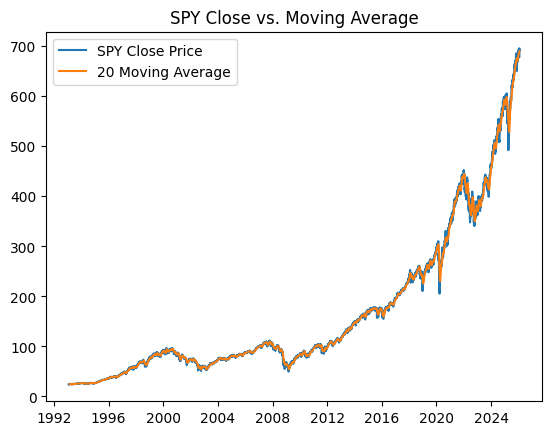

In [ ]:
TICKER = 'SPY'

WINDOW = (20)

df = yf.Ticker(TICKER).history(period="max")
df['MA'] = df['Close'].rolling(WINDOW).mean()

plt.plot(df['Close']) 
plt.plot(df['MA'])
plt.legend([f'{TICKER} Close Price', f'{WINDOW} Moving Average'])
plt.title(f'{TICKER} Close vs. Moving Average')

In [ ]:
df.columns = df.columns.get_level_values(0)


def add_ma_strategy(df):
    df['Strategy'] = np.where(df['Close'] > df['MA'], 1, -1)

    return df


df = add_ma_strategy(df)
df['asset_cumulative'] = np.cumprod(1 + df['Close'].pct_change()) - 1  # This shows what the multiplier would have been if you bought and held for 50 years.
df['strategy_cumulative'] =  np.cumprod(1 + df['Close'].pct_change() * df['Strategy'].shift()) - 1 

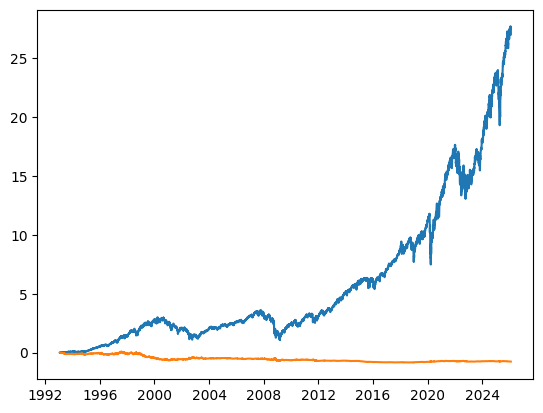

In [ ]:
plt.plot(df['asset_cumulative'])
plt.plot(df['strategy_cumulative'])

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains,MA,Strategy,asset_cumulative,strategy_cumulative
Date,,,,,,,,,,,,
2025-02-28 00:00:00-05:00,578.763503,587.817158,575.679721,587.283447,88744100,0.0,0.0,0.0,595.288925,NaN,NaN,NaN
2025-03-03 00:00:00-05:00,589.260195,590.406764,573.169186,576.994263,74249200,0.0,0.0,0.0,594.396899,-1.0,-0.017520,0.017520
2025-03-04 00:00:00-05:00,572.981447,578.595513,565.608012,570.164490,109648200,0.0,0.0,0.0,593.363535,-1.0,-0.029149,0.029564
2025-03-05 00:00:00-05:00,569.996421,578.091363,566.428337,576.292480,71230500,0.0,0.0,0.0,592.438397,-1.0,-0.018715,0.018499
2025-03-06 00:00:00-05:00,568.800430,573.435996,563.502657,566.062622,80094900,0.0,0.0,0.0,590.881183,-1.0,-0.036134,0.036578
...,...,...,...,...,...,...,...,...,...,...,...,...
2026-01-26 00:00:00-05:00,690.489990,694.130005,689.919983,692.729980,60473800,0.0,0.0,0.0,689.002994,1.0,0.179550,-0.083667
2026-01-27 00:00:00-05:00,694.179993,696.530029,693.570007,695.489990,55506100,0.0,0.0,0.0,689.261993,1.0,0.184249,-0.080016
2026-01-28 00:00:00-05:00,697.049988,697.840027,693.940002,695.419983,61172200,0.0,0.0,0.0,689.640494,1.0,0.184130,-0.080109


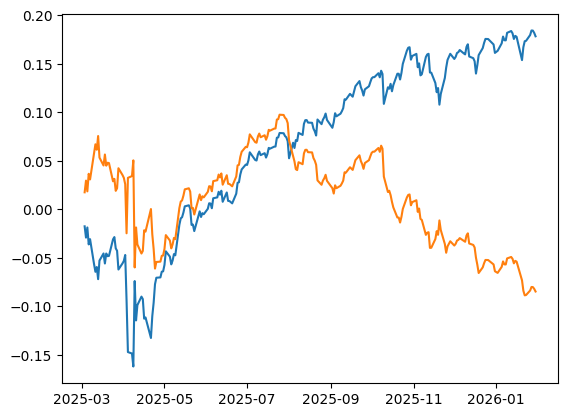

In [ ]:
def get_data():
    df = yf.Ticker(TICKER).history(period="1y")
    df.columns = df.columns.get_level_values(0)
    df['MA'] = df['Close'].rolling(WINDOW).mean()

    return df.dropna()


def add_strategy(df):
    df.columns = df.columns.get_level_values(0)
    df['Strategy'] = np.where(df['Close'] > df['MA'], 1, -1)
    df['Strategy'] = df['Strategy'].shift(1)
    return df


def test_strategy(df):
    df['asset_cumulative'] = np.cumprod(1 + df['Close'].pct_change()) - 1
    df['strategy_cumulative'] = np.cumprod(1 + df['Close'].pct_change() * df['Strategy']) - 1
    plt.plot(df['asset_cumulative'])
    plt.plot(df['strategy_cumulative'])
    return df


def main():
    df = get_data()
    df = add_strategy(df)
    df = test_strategy(df)
    return df


main()

## Moving average crossover

62/91 EMA crossover on SPY.

[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Close,High,Low,Open,Volume,62_ma,91_ma,Strategy,Asset_Returns,Strategy_Returns
1,685.400024,685.400024,688.739990,678.130005,679.650024,127844500,681.553085,681.532988,-1.0,0.011541,-0.011541
2,688.979980,688.979980,691.130005,686.919983,689.849976,77112200,684.108999,684.070073,1.0,0.016825,-0.006378
3,689.229980,689.229980,690.960022,687.159973,688.150024,63059600,685.451847,685.402885,1.0,0.017193,-0.006018
4,692.729980,692.729980,694.130005,689.919983,690.489990,60473800,687.002874,686.933418,1.0,0.022359,-0.000970
5,695.489990,695.489990,696.530029,693.570007,694.179993,55506100,688.533880,688.439005,1.0,0.026432,0.003010
6,695.419983,695.419983,697.840027,693.940002,697.049988,61172200,689.615324,689.503233,1.0,0.026329,0.002909
7,694.039978,694.039978,697.059998,684.830017,696.390015,97486200,690.232829,690.114896,1.0,0.024292,0.000919
8,691.969971,691.969971,694.210022,687.119995,691.789978,101835100,690.451671,690.339595,1.0,0.021237,-0.002066
9,695.409973,695.409973,696.929993,689.419983,689.580017,79286500,691.022516,690.898232,1.0,0.026314,0.002895
10,689.530029,689.530029,696.960022,684.030029,696.210022,107904600,690.863912,690.759736,1.0,0.017636,-0.005585


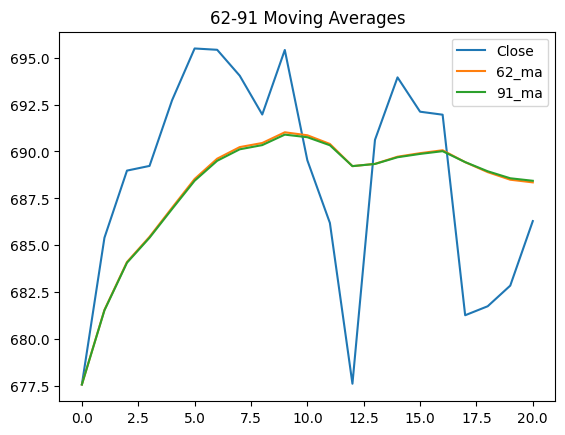

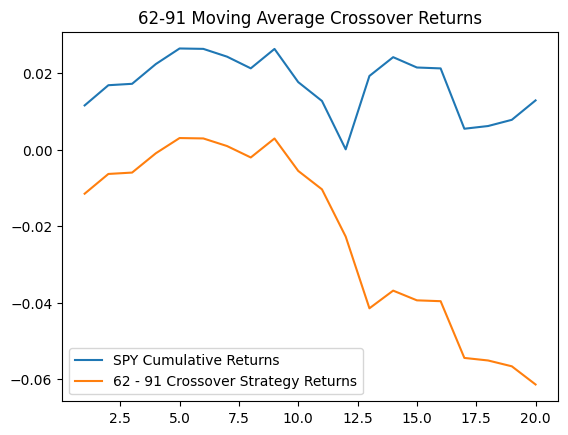

In [ ]:
TICKER = 'SPY'
INTERVAL='1d'

if INTERVAL == '1h':
    PERIOD = '730d'
else:
    PERIOD = 'max'
LOOKBACK = 10000

FAST = 62
SLOW = 91

def get_data(ticker=TICKER, lookback=LOOKBACK, interval=INTERVAL):

    df = yf.download(ticker, interval=interval, auto_adjust=False)
    df.columns = df.columns.get_level_values(0)

    df = df.reset_index(drop=True)

    return df.iloc[-lookback:, :]

def add_moving_averages(df, fast, slow):
    df[f'{FAST}_ma'] = df['Close'].ewm(span=fast).mean()
    df[f'{SLOW}_ma'] = df['Close'].ewm(span=slow).mean()

    plt.plot(df['Close'])
    plt.plot(df[f'{FAST}_ma'])
    plt.plot(df[f'{SLOW}_ma'])
    plt.legend(['Close', f'{FAST}_ma', f'{SLOW}_ma'])
    plt.title(f'{FAST}-{SLOW} Moving Averages');
    return df.dropna()

def add_strategy(df, fast, slow):
    df['Strategy'] = np.where(df[f'{fast}_ma'] > df[f'{slow}_ma'], 1, -1)
    df['Strategy'] = df['Strategy'].shift(1)
    return df

def test_strategy(df, ticker, fast, slow):
    df['Asset_Returns'] = (1 + df['Close'].pct_change()).cumprod() - 1
    df['Strategy_Returns'] = (1 + df['Close'].pct_change() * df['Strategy']).cumprod() -1

    plt.figure()
    plt.plot(df['Asset_Returns'])
    plt.plot(df['Strategy_Returns'])
    plt.legend([f'{ticker} Cumulative Returns', f'{fast} - {slow} Crossover Strategy Returns'])
    plt.title(f'{FAST}-{SLOW} Moving Average Crossover Returns'); 

    return df.dropna()

def main():
    df = get_data()
    df = add_moving_averages(df, FAST, SLOW)
    df = add_strategy(df, FAST, SLOW)
    df = test_strategy(df, TICKER, FAST, SLOW)

    return df

main()

## Crossover parameter sweep

Grid search over fast/slow EMA spans on GBP/USD.

[*********************100%***********************]  1 of 1 completed


1081 combinations tested


Price,Adj Close,Close,High,Low,Open,Volume,48_ma,49_ma,Strategy,Asset_Returns,Strategy_Returns
1,1.363829,1.363829,1.365262,1.362212,1.363791,0,1.364576,1.364576,-1.0,-0.001118,0.001118
2,1.364703,1.364703,1.365001,1.358511,1.364629,0,1.364620,1.364620,-1.0,-0.000478,0.000476
3,1.359693,1.359693,1.360359,1.357128,1.359989,0,1.363311,1.363312,-1.0,-0.004147,0.004149
4,1.359712,1.359712,1.359989,1.353052,1.359675,0,1.362530,1.362532,-1.0,-0.004134,0.004136
5,1.354041,1.354041,1.356466,1.353491,1.354041,0,1.360963,1.360969,-1.0,-0.008287,0.008323
6,1.355014,1.355014,1.356116,1.352484,1.354830,0,1.360004,1.360010,-1.0,-0.007574,0.007599
7,1.351534,1.351534,1.351534,1.347527,1.351351,0,1.358784,1.358793,-1.0,-0.010123,0.010186
8,1.348363,1.348363,1.354280,1.348072,1.348199,0,1.357424,1.357437,-1.0,-0.012445,0.012556
9,1.353180,1.353180,1.354903,1.348963,1.352850,0,1.356916,1.356929,-1.0,-0.008918,0.008939
10,1.351717,1.351717,1.355014,1.350621,1.351845,0,1.356339,1.356352,-1.0,-0.009989,0.010030


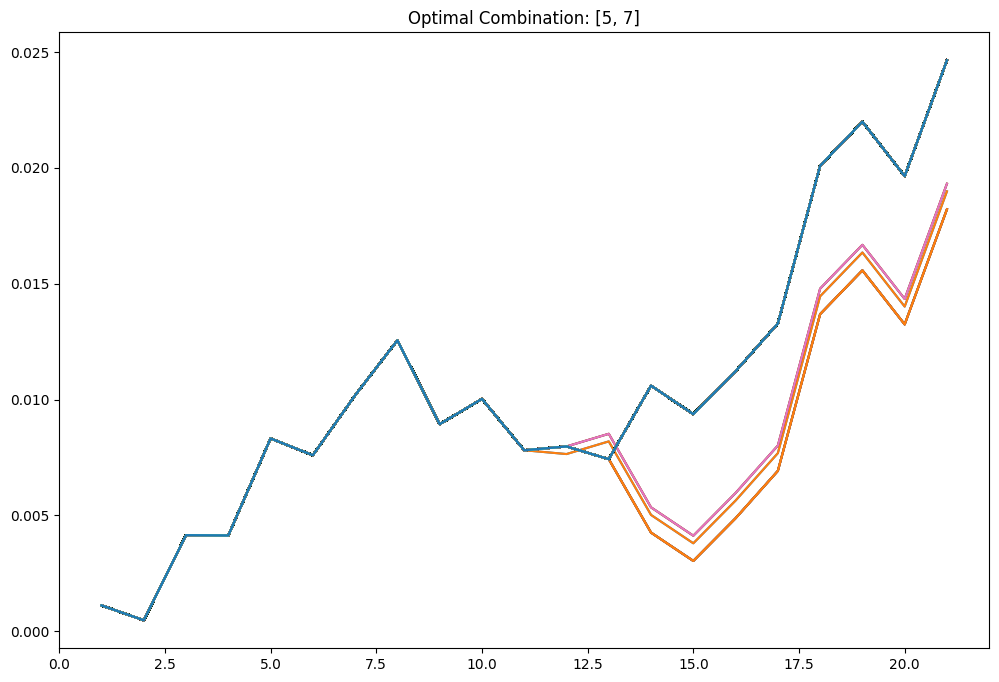

In [ ]:
TICKER = 'GBPUSD=X'
INTERVAL='1d'


if INTERVAL == '1h':
    PERIOD = '730d'
else:
    PERIOD = 'max'
LOOKBACK = 10000


FAST = list(range(3, 50))
SLOW = list(range(4, 50))


def get_data(ticker=TICKER, lookback=LOOKBACK, interval=INTERVAL):
    df = yf.download(ticker, interval=interval, auto_adjust=False)
    df.columns = df.columns.get_level_values(0)

    df = df.reset_index(drop=True)

    return df.iloc[-lookback:, :]


def add_moving_averages(df, fast, slow):
    df[f'{fast}_ma'] = df['Close'].ewm(span=fast).mean()
    df[f'{slow}_ma'] = df['Close'].ewm(span=slow).mean()

    return df.dropna()


def add_strategy(df, fast, slow):
    df['Strategy'] = np.where(df[f'{fast}_ma'] > df[f'{slow}_ma'], 1, -1)
    df['Strategy'] = df['Strategy'].shift(1)
    return df


def test_strategy(df):
    df['Asset_Returns'] = (1 + df['Close'].pct_change()).cumprod() - 1
    df['Strategy_Returns'] = (1 + df['Close'].pct_change() * df['Strategy']).cumprod() -1

    plt.plot(df['Strategy_Returns'])    
    return df.dropna()


def main():
    base = get_data()
    plt.figure(figsize=(12, 8))
    legend_list = []

    best_returns = -np.inf
    best_params = None

    count = 0
    for s in SLOW:
        for f in FAST:
            if f < s:
                df = base.copy()
                df = add_moving_averages(df, f, s)
                df = add_strategy(df, f, s)
                df = test_strategy(df)
                legend_list.append(f'{f}, {s} cross')

                returns = float(df['Strategy_Returns'].iloc[-1])
                if returns > best_returns:
                    best_returns = returns
                    best_params = [f, s]
                
                count += 1

    plt.title(f'Optimal Combination: {best_params}')
    print(f'{count} combinations tested')
    return df

main()

## MACD

Long/short on the sign of the MACD histogram (SPY, 1m bars).

[*********************100%***********************]  1 of 1 completed


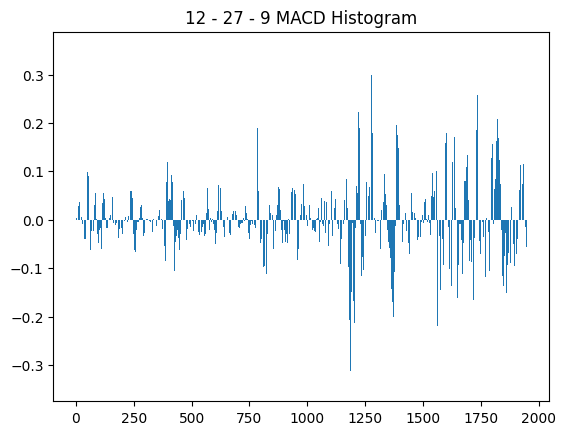

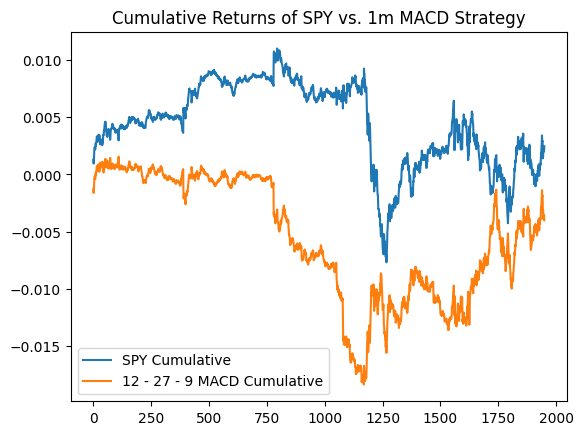

In [ ]:
TICKER = 'SPY'
INTERVAL='1m'


# set period based on interval
if INTERVAL == '1h':
    PERIOD = '730d'
else:
    PERIOD = 'max'
MACD_FAST = 12
MACD_SLOW = 27
MACD_SPAN = 9
LOOKBACK = 10000


def get_data(ticker=TICKER, lookback=LOOKBACK, interval=INTERVAL):
    # get data at interval you want
    df = yf.download(ticker, interval=interval, period=PERIOD)
    df.columns = df.columns.get_level_values(0)

    # reset the index to make plots prettier
    df = df.reset_index(drop=True)

    # only return the subset of data you are interested in
    return df.iloc[-lookback:, :]


def add_MACD(df, fast=MACD_FAST, slow=MACD_SLOW, span=MACD_SPAN):
    df[f'{fast}_ema'] = df['Close'].ewm(span=fast).mean()
    df[f'{slow}_ema'] = df['Close'].ewm(span=slow).mean()

    # macd line is the difference betweent he fast and slow
    df[f'MACD'] = df[f'{fast}_ema'] - df[f'{slow}_ema']

    # macd signal is a 9-period moving average of this line
    df['Signal'] = df['MACD'].ewm(span=span).mean()

    # MACD histogram is almost always what is used in TA
    df['MACD_hist'] = df['MACD'] - df['Signal']

    # plot the histogram
    plt.bar(x=range(len(df)), height=df['MACD_hist'])
    plt.title(f'{MACD_FAST} - {MACD_SLOW} - {MACD_SPAN} MACD Histogram')

    return df


def add_strategy(df):
    df['Strategy'] = 0
    df['Strategy'] = np.where(df['MACD_hist'] > 0, 1, -1)
    df['Strategy'] = df['Strategy'].shift(1)
    return df


def test_strategy(df):
    df['Asset_Returns'] = (1 + df['Close'].pct_change()).cumprod() - 1
    df['Strategy_Returns'] = (1 + df['Close'].pct_change() * df['Strategy']).cumprod() -1

    plt.figure()
    plt.title(f'Cumulative Returns of {TICKER} vs. {INTERVAL} MACD Strategy')
    plt.plot(df['Asset_Returns'])
    plt.plot(df['Strategy_Returns'])
    plt.legend([f'{TICKER} Cumulative', f'{MACD_FAST} - {MACD_SLOW} - {MACD_SPAN} MACD Cumulative'])

    return df


def main():
    df = get_data()
    df = add_MACD(df)
    df = add_strategy(df)
    df = test_strategy(df)

    return df


df = main()

## MACD + Bollinger Bands

Trade only when the MACD and Bollinger Band signals agree.

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume,12_ema,27_ema,MACD,Signal,MACD_hist,BB_SMA,BB_STD,Upper_Band,Lower_Band,MACD_Strategy,BB_Strategy,Full_Strategy,Strategy,Asset_Returns,Strategy_Returns
7341,427.451019,427.460517,422.014082,423.133727,64736900,416.561691,412.945586,3.616105,1.623380,1.992724,410.451292,10.435530,420.886822,400.015763,NaN,NaN,NaN,0,NaN,NaN
7342,429.538483,429.813660,425.496339,428.086731,77101300,418.619765,414.447601,4.172164,2.137883,2.034282,411.224406,11.258522,422.482928,399.965884,1.0,-1.0,0.0,0,0.004884,0.000000
7343,432.593811,432.593811,427.042986,428.940702,68529800,420.825523,416.059449,4.766073,2.667428,2.098645,412.203259,12.231555,424.434815,399.971704,1.0,-1.0,0.0,0,0.012031,0.000000
7344,437.945435,438.438859,433.798929,436.493683,86581500,423.517077,417.970243,5.546834,3.246729,2.300105,413.764214,13.429229,427.193442,400.334985,1.0,-1.0,0.0,0,0.024551,0.000000
7345,435.241150,437.613295,433.125186,436.797262,79666900,425.354115,419.454541,5.899574,3.779815,2.119759,414.815837,14.263465,429.079302,400.552372,1.0,-1.0,0.0,0,0.018225,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8317,681.750000,686.280029,677.520020,681.690002,96267500,687.911721,688.116626,-0.204905,1.026070,-1.230975,689.145996,5.704369,694.850366,683.441627,-1.0,1.0,0.0,0,0.594920,-0.060426
8318,682.849976,684.940002,675.780029,680.140015,81354700,687.132991,687.740436,-0.607445,0.699367,-1.306813,688.705496,5.838600,694.544096,682.866896,-1.0,1.0,0.0,0,0.597493,-0.060426
8319,686.289978,689.150024,682.830017,684.020020,73570300,687.003297,687.636832,-0.633535,0.432787,-1.066322,689.140994,5.261384,694.402378,683.879610,-1.0,1.0,0.0,0,0.605541,-0.060426
8320,684.479980,686.179993,681.549988,683.840027,58649400,686.615094,687.411343,-0.796249,0.186980,-0.983228,689.094992,5.299697,694.394689,683.795295,-1.0,0.0,-1.0,0,0.601306,-0.060426


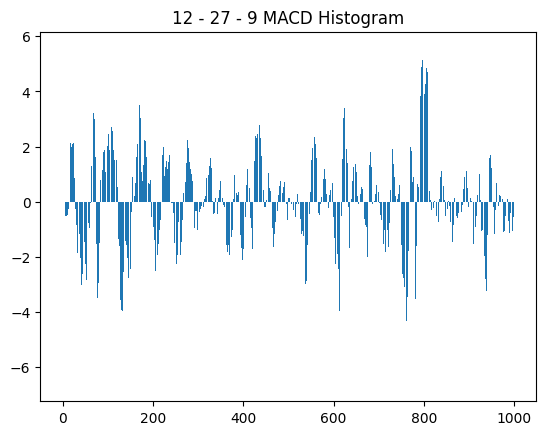

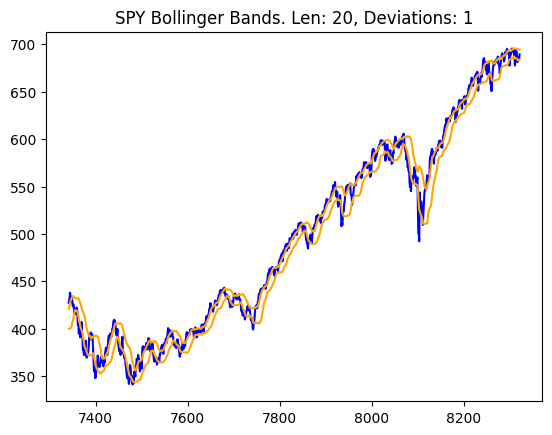

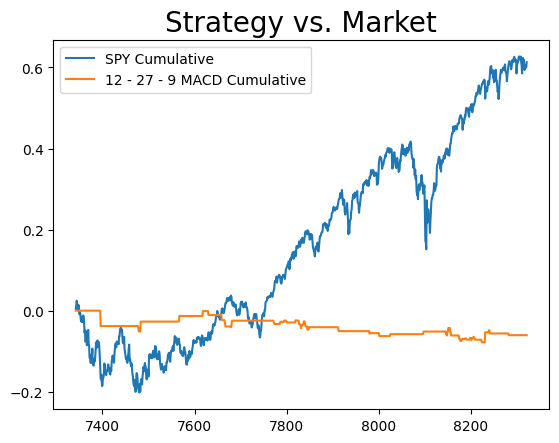

In [ ]:
TICKER = 'SPY'
INTERVAL='1d'

if INTERVAL == '1h':
    PERIOD = '730d'
else:
    PERIOD = 'max'

MACD_FAST = 12
MACD_SLOW = 27
MACD_SPAN = 9
BB_LEN = 20
DEVS = 1

LOOKBACK = 1000

def get_data(ticker=TICKER, lookback=LOOKBACK, interval=INTERVAL):

    df = yf.download(ticker, interval=interval, period=PERIOD)
    df.columns = df.columns.get_level_values(0)

    df = df.reset_index(drop=True)

    return df.iloc[-lookback:, :]

def add_MACD(df, fast=MACD_FAST, slow=MACD_SLOW, span=MACD_SPAN):

    df[f'{fast}_ema'] = df['Close'].ewm(span=fast).mean()
    df[f'{slow}_ema'] = df['Close'].ewm(span=slow).mean()

    df[f'MACD'] = df[f'{fast}_ema'] - df[f'{slow}_ema']

    df['Signal'] = df['MACD'].ewm(span=span).mean()

    df['MACD_hist'] = df['MACD'] - df['Signal']

    plt.bar(x=range(len(df)), height=df['MACD_hist'])
    plt.title(f'{MACD_FAST} - {MACD_SLOW} - {MACD_SPAN} MACD Histogram')

    return df

def add_MACD_strategy(df):

    df['MACD_Strategy'] = 0
    df['MACD_Strategy'] = np.where(df['MACD_hist'] > 0, 1, -1)
    df['MACD_Strategy'] = df['MACD_Strategy'].shift(1)
    
    return df

def add_bollinger_bands(df, devs=DEVS, bb_len=BB_LEN):

    df['BB_SMA'] = df['Close'].rolling(bb_len).mean()

    df['BB_STD'] = df['Close'].rolling(bb_len).std()

    df['Upper_Band'] = df['BB_SMA'] + (devs * df['BB_STD'])
    df['Lower_Band'] = df['BB_SMA'] - (devs * df['BB_STD'])

    df = df.dropna()

    plt.figure()
    plt.plot(df['Close'], color='blue')
    plt.plot(df['Upper_Band'], color='orange')
    plt.plot(df['Lower_Band'], color='orange')

    plt.title(f'{TICKER} Bollinger Bands. Len: {BB_LEN}, Deviations: {DEVS}');

    return df

def add_BB_strategy(df):
    df['BB_Strategy'] = 0
    df['BB_Strategy'] = np.where(
        df['Close'] > df['Upper_Band'], -1, 
        np.where(df['Close'] < df['Lower_Band'], 1, 0)
        )
    
    df['BB_Strategy'] = df['BB_Strategy'].shift(1)
    
    return df

def add_full_strategy(df):

    df['Full_Strategy'] = df['MACD_Strategy'] + df['BB_Strategy']

    df['Strategy'] = np.where(df['Full_Strategy'] == 2, 1, 
                     np.where(df['Full_Strategy'] == -2, -1, 0))

    return df

def test_strategy(df):

    df['Asset_Returns'] = (1 + df['Close'].pct_change()).cumprod() - 1
    df['Strategy_Returns'] = (1 + df['Close'].pct_change() * df['Strategy']).cumprod() -1

    plt.figure()
    plt.plot(df['Asset_Returns'])
    plt.plot(df['Strategy_Returns'])
    plt.legend([f'{TICKER} Cumulative', f'{MACD_FAST} - {MACD_SLOW} - {MACD_SPAN} MACD Cumulative'])
    plt.title('Strategy vs. Market', size='20')

    return df

def main():
    df = get_data()
    df = add_MACD(df)
    df = add_bollinger_bands(df)
    df = add_MACD_strategy(df)
    df = add_BB_strategy(df)
    df = add_full_strategy(df)
    df = test_strategy(df)

    return df

df = main()
df